In [ ]:
# DS4400 HW 4
# Eunchae Hong
# Problem 1: Decision Trees

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score
)
import matplotlib.pyplot as plt

# load the spam database in
spam_data = pd.read_csv("spambase/spambase.data", header = None)

In [ ]:
'''
    Part 1
    Use an existing package to train a decision tree on the SPAMBASE training data, without pruning.
    Use the information gain splitting criteria. 
    Compute the training and the testing error, accuracy, F1 score, and AUC and report these metrics. 
    Write down some observations about the training and testing metrics.
'''

# train test split on the data set
X = spam_data.iloc[:, :-1].values
y = spam_data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 5)

model = DecisionTreeClassifier(
        criterion = "entropy",
        random_state = 5
    )

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

y_prob_test  = model.predict_proba(X_test)[:, 1]
y_prob_train = model.predict_proba(X_train)[:, 1]

# training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_error = 1 - train_accuracy
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_prob_train)

print("Training Metrics - Information Gain")
print("-" * 20)
print(f"Accuracy: {round(train_accuracy, 3)}\nError: {round(train_error, 3)}")
print(f"F1 Score: {round(train_f1, 3)}\nAUC: {round(train_auc, 3)}")

# testing metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_error = 1 - test_accuracy
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob_test)

print("Testing Metrics - Information Gain")
print("-" * 20)
print(f"Accuracy: {round(test_accuracy, 3)}\nError: {round(test_error, 3)}")
print(f"F1 Score: {round(test_f1, 3)}\nAUC: {round(test_auc, 3)}")


Training Metrics
--------------------
Accuracy: 0.999
Error: 0.001
F1 Score: 0.999
AUC: 1.0
Testing Metrics
--------------------
Accuracy: 0.93
Error: 0.07
F1 Score: 0.909
AUC: 0.928


***Part 1 Question: Write down some observations about the training and testing metrics.***

The training and testing metrics are both relatively high, however the training metrics are almost perfect, indicating that there may be some overfitting in the model. Without pruning it makes it harder for the mdoel to learn generalized patterns and may be more likely to just learning the testing set. On the other hand since the testing metrics are still pretty high, it shows that the model still perfromed well on data it has never seen before.

In [ ]:
''' 
    Part 2
    Change the splitting criteria to use the Gini index and report the same metrics. 
    Compare them to the information gain metrics.
'''

# the metrics are exactly the same
gini_model = DecisionTreeClassifier(
    criterion = "gini",
    random_state = 5
)

gini_model.fit(X_train, y_train)


gini_y_train_pred = gini_model.predict(X_train)
gini_y_pred = gini_model.predict(X_test)

# training metrics
gini_train_accuracy = accuracy_score(y_train, gini_y_train_pred)
gini_train_error = 1 - gini_train_accuracy
gini_train_f1 = f1_score(y_train, gini_y_train_pred)
gini_train_auc = roc_auc_score(y_train, gini_y_train_pred)

print("Training Metrics - Gini")
print("-" * 20)
print(f"Accuracy: {round(gini_train_accuracy, 3)}\nError: {round(gini_train_error, 3)}")
print(f"F1 Score: {round(gini_train_f1, 3)}\nAUC: {round(gini_train_auc, 3)}")

# testing metrics
gini_test_accuracy = accuracy_score(y_test, gini_y_pred)
gini_test_error = 1 - gini_test_accuracy
gini_test_f1 = f1_score(y_test, gini_y_pred)
gini_test_auc = roc_auc_score(y_test, gini_y_pred)

print("Testing Metrics - Gini")
print("-" * 20)
print(f"Accuracy: {round(gini_test_accuracy, 3)}\nError: {round(gini_test_error, 3)}")
print(f"F1 Score: {round(gini_test_f1, 3)}\nAUC: {round(gini_test_auc, 3)}")

Training Metrics
--------------------
Accuracy: 0.999
Error: 0.001
F1 Score: 0.999
AUC: 0.999
Testing Metrics
--------------------
Accuracy: 0.925
Error: 0.075
F1 Score: 0.904
AUC: 0.922


***Part 2 Question: Compare them to the information gain metrics.***

The training metrics from the Gini model are nearly identical to the information gain metrics as they are also near perfect. Additionally while the testing metrics are also relativley high here too there is also a slightly larger gap between training and testing here compared to the information gain metrics. I would also make the inference that there also may be some overfitting in this model as well. Showing that without pruning in both instances it can create overfitting in models.

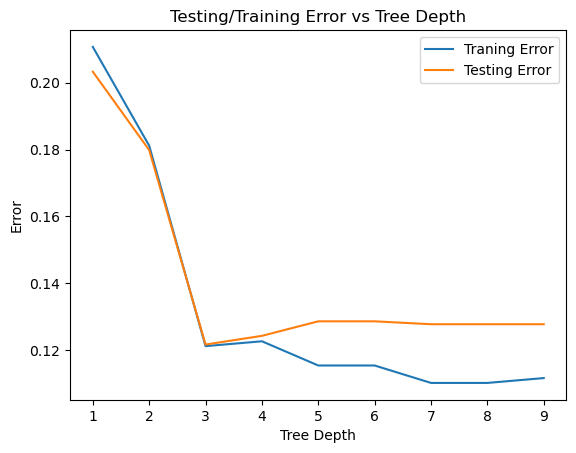

In [7]:
'''
    Part 3
    Implement a pruning criteria that sets an upper bound on the maximum depth of the tree. 
    Generate a graph that plots the training and testing error as a function of the tree depth on the SPAMBASE data. 
    Please explain your observations. What is the optimal depth of the tree that you would recommend based on this analysis?
'''
# set a range for different depths
depths = range(1, 10)

training_errors = []
testing_errors = []

for val in depths:
    model = DecisionTreeClassifier(
        class_weight = "balanced",
        max_depth = val,
        min_samples_leaf = 50,
        random_state = 5
    )
    
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    training_errors.append((1 - accuracy_score(y_train, y_train_pred)))
    testing_errors.append((1 - accuracy_score(y_test, y_test_pred)))

# generate a graph that plots the training and testing error
plt.plot(depths, training_errors, label = "Traning Error")
plt.plot(depths, testing_errors, label = "Testing Error")
plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Testing/Training Error vs Tree Depth")
plt.legend()
plt.show()

***Part 3 Question: Please explain your observations. What is the optimal depth of the tree that you would recommend based on this analysis?***

Initially the training and testing error see a steep decline in error from depth 1 to 3. However after the depth of 3 the error starts moving in different directions. The training error continues to overall decline, which may hint at overfitting in the model, while the testing error starts to increase after the depth of 3. The optimal depth that I would recommend based on this analysis would be a depth of 3 becuase it has a low error for both training and testing, without a big gap therefore hypothetically avoiding overfitting.